# Statistical Analysis: Cat Robot Drop Test

**Goal:** Test if morphology (spine+tail vs spine-only) affects reorientation performance

**Problem:** Initial conditions (angles and velocities at release) vary randomly due to drop rig issues

**Solution:** Use Linear Mixed Model (LMM) to control for initial condition variability

**Measurement:** Front IMU only

**Outcomes:** |Roll angle|, |Roll rate|, |Pitch angle|, |Pitch rate| at 2.5m — absolute values because deviation from zero in either direction is equally bad

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## 1. Load Data and Create Variables

In [2]:
df = pd.read_csv('report.csv')

print(f"Total drops: {len(df)}")
print(f"Morphologies: {df['morphology'].unique()}")
print(f"Trials: {df['trial'].unique()}")
print(f"\nDrops per morphology:")
print(df['morphology'].value_counts())
print(f"\nDrops per trial:")
print(df['trial'].value_counts())

Total drops: 50
Morphologies: ['spine+tail' 'spine-only']
Trials: ['r45' 'r90' 'r180' 'r180_p-15' 'r180_p15']

Drops per morphology:
morphology
spine+tail    25
spine-only    25
Name: count, dtype: int64

Drops per trial:
trial
r45          10
r90          10
r180         10
r180_p-15    10
r180_p15     10
Name: count, dtype: int64


In [3]:
# Front IMU only, with angle wrapping fix
#
# IMPORTANT: F_roll values can exceed ±180° due to np.unwrap() in the processing pipeline.
# Taking abs() of 355° would give 355°, but physically that's only 5° from upright.
# We use shortest angular distance instead: wrap to [-180, 180], then abs().

def angular_distance(angle):
    '''Shortest angular distance from 0. Handles wrapped angles correctly.'''
    return np.abs(((angle + 180) % 360) - 180)

def wrap_angle(angle):
    '''Wrap signed angle to [-180, 180].'''
    return ((angle + 180) % 360) - 180

# Outcomes: shortest angular distance from upright
df['abs_roll_2p5m']      = angular_distance(df['F_roll_2p5m'])
df['abs_pitch_2p5m']     = angular_distance(df['F_pitch_2p5m'])
df['abs_rollrate_2p5m']  = df['F_rollrate_2p5m'].abs()  # rates don't wrap
df['abs_pitchrate_2p5m'] = df['F_pitchrate_2p5m'].abs()

# Initial conditions: wrap angles, keep rates signed
df['roll_initial']      = wrap_angle(df['F_roll_initial'])
df['pitch_initial']     = wrap_angle(df['F_pitch_initial'])
df['rollrate_initial']  = df['F_rollrate_initial']
df['pitchrate_initial'] = df['F_pitchrate_initial']

print(f"Roll outcome range: [{df['abs_roll_2p5m'].min():.1f}, {df['abs_roll_2p5m'].max():.1f}] (should be ≤ 180)")
print(f"Pitch outcome range: [{df['abs_pitch_2p5m'].min():.1f}, {df['abs_pitch_2p5m'].max():.1f}] (should be ≤ 180)")
df[['morphology', 'trial', 'abs_roll_2p5m', 'abs_rollrate_2p5m', 'abs_pitch_2p5m', 'abs_pitchrate_2p5m']].head(10)

Roll outcome range: [0.3, 159.4] (should be ≤ 180)
Pitch outcome range: [0.6, 56.2] (should be ≤ 180)


,morphology,trial,abs_roll_2p5m,abs_rollrate_2p5m,abs_pitch_2p5m,abs_pitchrate_2p5m
0,spine+tail,r45,23.85,0.72,15.14,151.54
1,spine+tail,r90,33.30,91.58,29.79,51.37
2,spine+tail,r180,30.28,40.78,11.49,46.37
3,spine+tail,r180_p-15,58.16,39.21,42.39,44.39
4,spine+tail,r180_p15,15.09,19.82,0.75,409.10
5,spine+tail,r45,0.34,21.49,22.77,58.66
6,spine+tail,r90,32.48,128.37,1.05,273.24
7,spine+tail,r180,16.03,271.16,2.14,317.11
8,spine+tail,r180_p-15,70.42,53.17,18.31,202.06
9,spine+tail,r180_p15,67.44,3.47,6.88,18.24


## 2. Diagnostic Check: Are Initial Conditions Confounded?

**Question:** Within each trial type, does morphology systematically affect initial conditions?

**Method:** Two-way ANOVA: `Initial_Condition ~ Morphology + Trial`
- Look at **Morphology** p-value only (controlling for Trial)
- p > 0.05 → random ✅, p < 0.05 → confounded ⚠️

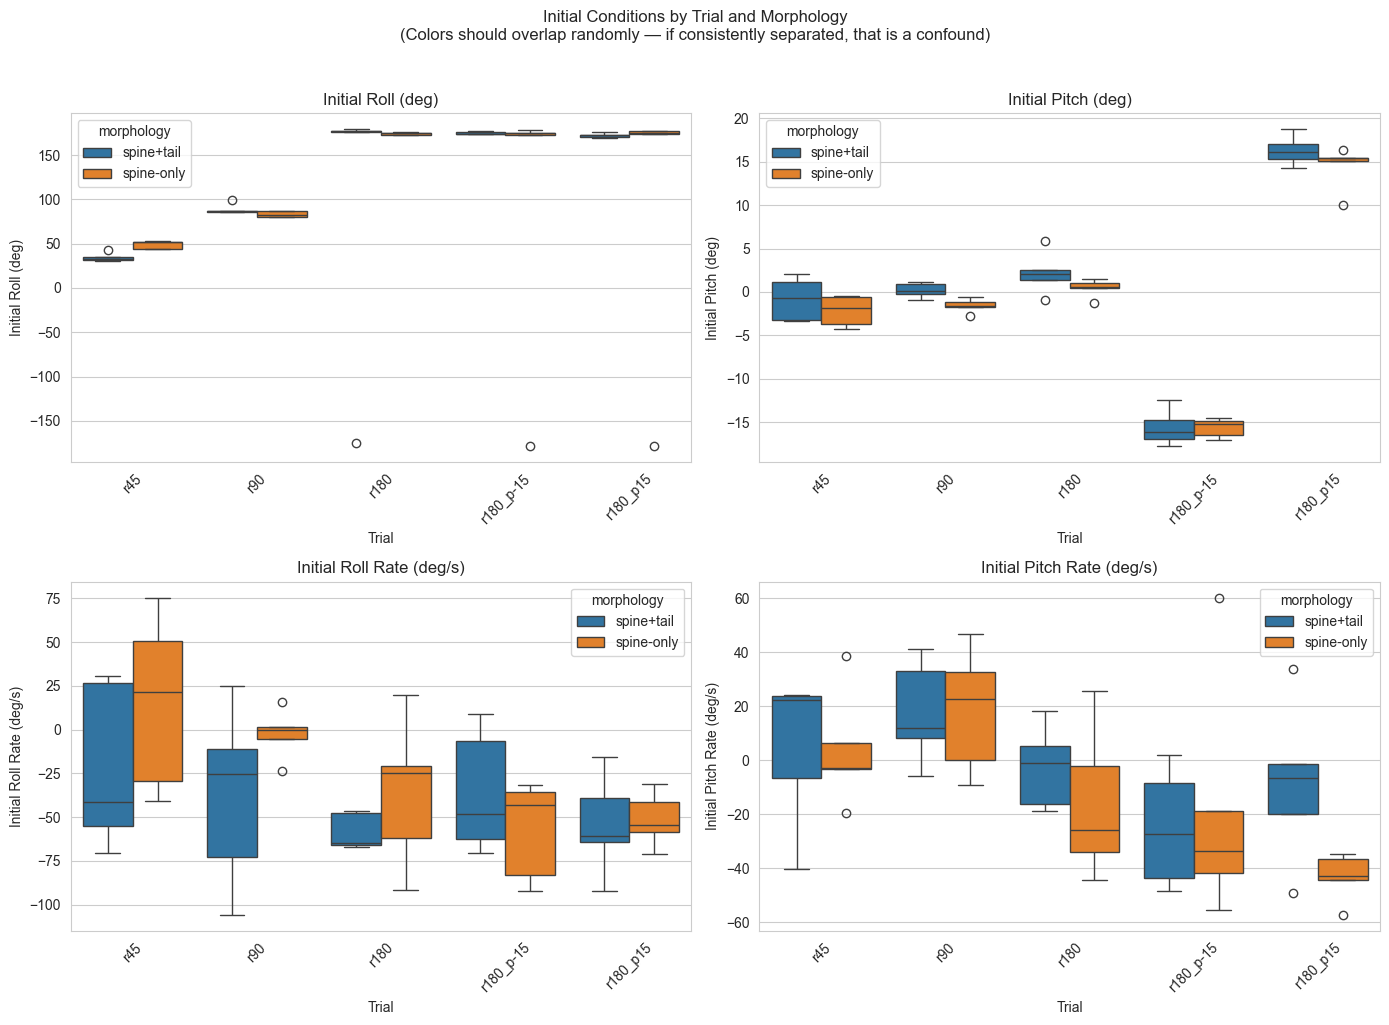

In [4]:
# Visualize initial conditions by trial and morphology
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

initial_vars = [
    ('roll_initial',      'Initial Roll (deg)'),
    ('pitch_initial',     'Initial Pitch (deg)'),
    ('rollrate_initial',  'Initial Roll Rate (deg/s)'),
    ('pitchrate_initial', 'Initial Pitch Rate (deg/s)')
]

for idx, (var, label) in enumerate(initial_vars):
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=axes[idx])
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel(label)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Initial Conditions by Trial and Morphology\n(Colors should overlap randomly — if consistently separated, that is a confound)', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Two-way ANOVA: Initial_Condition ~ Morphology + Trial
print("="*80)
print("DIAGNOSTIC: Does morphology affect initial conditions (controlling for trial)?")
print("="*80)

diagnostic_results = []

for var, label in initial_vars:
    model = smf.ols(f"{var} ~ C(morphology) + C(trial)", data=df).fit()
    anova_table = anova_lm(model, typ=2)

    morph_f = anova_table.loc['C(morphology)', 'F']
    morph_p = anova_table.loc['C(morphology)', 'PR(>F)']
    result  = "✅ RANDOM" if morph_p >= 0.05 else "⚠️ CONFOUNDED"

    print(f"\n{label}")
    print(f"  Morphology effect: F = {morph_f:.3f}, p = {morph_p:.4f} → {result}")

    diagnostic_results.append({'Variable': label, 'F': morph_f, 'p-value': morph_p, 'Result': result})

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(pd.DataFrame(diagnostic_results).to_string(index=False))

confounded = any(r['Result'] == '⚠️ CONFOUNDED' for r in diagnostic_results)
if confounded:
    print("\n⚠️  Some initial conditions differ by morphology — LMM controls for this, but pitch interpretation is limited.")
else:
    print("\n✅ All initial conditions are random — morphology effects can be interpreted causally.")

DIAGNOSTIC: Does morphology affect initial conditions (controlling for trial)?

Initial Roll (deg)
  Morphology effect: F = 0.255, p = 0.6164 → ✅ RANDOM

Initial Pitch (deg)
  Morphology effect: F = 7.273, p = 0.0099 → ⚠️ CONFOUNDED

Initial Roll Rate (deg/s)
  Morphology effect: F = 2.306, p = 0.1360 → ✅ RANDOM

Initial Pitch Rate (deg/s)
  Morphology effect: F = 1.236, p = 0.2722 → ✅ RANDOM

SUMMARY
                  Variable        F  p-value        Result
        Initial Roll (deg) 0.254581 0.616385      ✅ RANDOM
       Initial Pitch (deg) 7.273403 0.009881 ⚠️ CONFOUNDED
 Initial Roll Rate (deg/s) 2.306146 0.136017      ✅ RANDOM
Initial Pitch Rate (deg/s) 1.236251 0.272233      ✅ RANDOM

⚠️  Some initial conditions differ by morphology — LMM controls for this, but pitch interpretation is limited.


## 3. Descriptive Statistics: Outcomes at 2.5m

In [6]:
outcomes = [
    ('abs_roll_2p5m',      '|Roll Angle| at 2.5m (deg)'),
    ('abs_rollrate_2p5m',  '|Roll Rate| at 2.5m (deg/s)'),
    ('abs_pitch_2p5m',     '|Pitch Angle| at 2.5m (deg)'),
    ('abs_pitchrate_2p5m', '|Pitch Rate| at 2.5m (deg/s)')
]

for var, label in outcomes:
    print(f"\n{label}:")
    print(df.groupby('morphology')[var].describe()[['mean', 'std', 'min', 'max', 'count']])


|Roll Angle| at 2.5m (deg):
               mean        std   min     max  count
morphology                                         
spine+tail  39.6604  35.099084  0.34  159.40   25.0
spine-only  26.1532  22.350364  1.38   76.81   25.0

|Roll Rate| at 2.5m (deg/s):
                mean        std   min     max  count
morphology                                          
spine+tail   75.1700  91.043782  0.00  330.48   25.0
spine-only  102.4004  66.722037  0.92  248.95   25.0

|Pitch Angle| at 2.5m (deg):
               mean        std   min    max  count
morphology                                        
spine+tail  16.4876  12.774517  0.75  42.39   25.0
spine-only  22.8512  17.108200  0.55  56.21   25.0

|Pitch Rate| at 2.5m (deg/s):
                mean        std   min     max  count
morphology                                          
spine+tail  119.0584  96.572406   0.0  409.10   25.0
spine-only  138.6012  87.843891  22.7  302.65   25.0


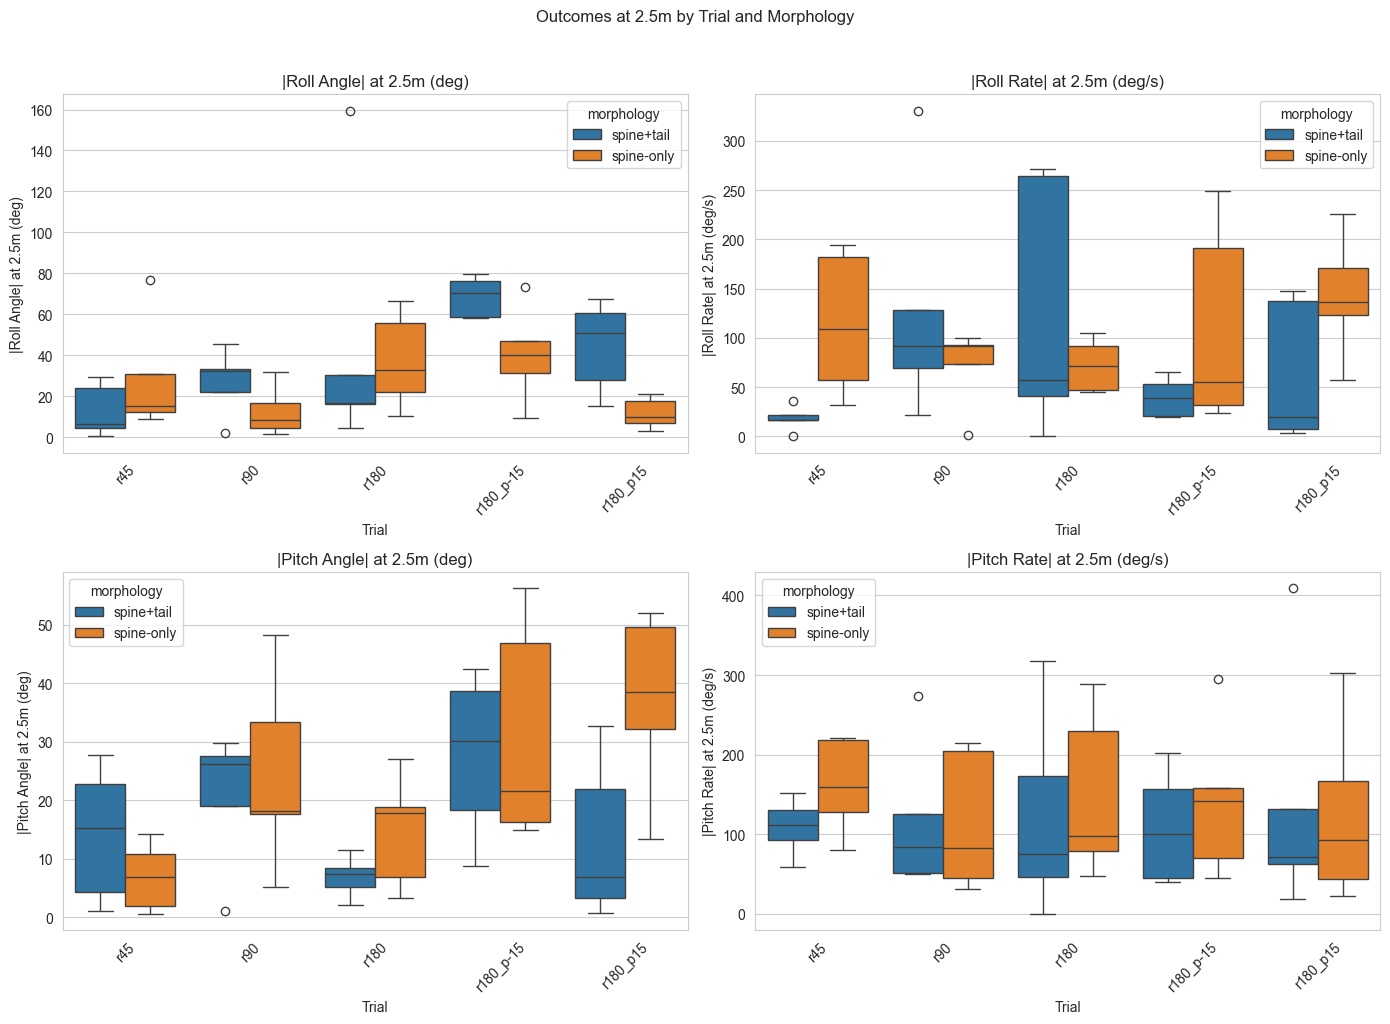

In [7]:
# Visualize outcomes by trial and morphology
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=axes[idx])
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel(label)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Outcomes at 2.5m by Trial and Morphology', y=1.02)
plt.tight_layout()
plt.show()

## 4. Main Analysis: Linear Model

**Model:** `|Outcome| ~ Morphology + Trial + Initial_Roll + Initial_Pitch + Initial_RollRate + Initial_PitchRate`

- Controls for trial type (intentional design) and initial condition noise (drop rig)
- Cluster-robust standard errors grouped by trial
- **Coefficient for `C(morphology)[T.spine-only]`** = how much spine-only differs from spine+tail

### 4.1 |Impact Roll Angle|

In [8]:
formula = "abs_roll_2p5m ~ C(morphology) + C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"
model_roll_angle = smf.ols(formula, data=df).fit()
print(model_roll_angle.summary())

                            OLS Regression Results                            
Dep. Variable:          abs_roll_2p5m   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     3.024
Date:                Thu, 30 Apr 2026   Prob (F-statistic):            0.00753
Time:                        01:22:54   Log-Likelihood:                -227.38
No. Observations:                  50   AIC:                             474.8
Df Residuals:                      40   BIC:                             493.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [9]:
coef = model_roll_angle.params['C(morphology)[T.spine-only]']
pval = model_roll_angle.pvalues['C(morphology)[T.spine-only]']
ci   = model_roll_angle.conf_int().loc['C(morphology)[T.spine-only]']

print(f"Morphology effect on |Impact Roll Angle|")
print(f"  Coefficient : {coef:.2f}° (spine-only vs spine+tail)")
print(f"  95% CI      : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"  p-value     : {pval:.4f}")
print(f"  R²          : {model_roll_angle.rsquared:.3f}")
print(f"  {'✅ SIGNIFICANT' if pval < 0.05 else '⚠️ NOT SIGNIFICANT'}")

Morphology effect on |Impact Roll Angle|
  Coefficient : -4.82° (spine-only vs spine+tail)
  95% CI      : [-20.81, 11.18]
  p-value     : 0.5463
  R²          : 0.405
  ⚠️ NOT SIGNIFICANT


### 4.2 |Impact Roll Rate|

In [10]:
formula = "abs_rollrate_2p5m ~ C(morphology) + C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"
model_roll_rate = smf.ols(formula, data=df).fit()
print(model_roll_rate.summary())

                            OLS Regression Results                            
Dep. Variable:      abs_rollrate_2p5m   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                 -0.031
Method:                 Least Squares   F-statistic:                    0.8338
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.590
Time:                        01:22:54   Log-Likelihood:                -285.36
No. Observations:                  50   AIC:                             590.7
Df Residuals:                      40   BIC:                             609.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [11]:
coef = model_roll_rate.params['C(morphology)[T.spine-only]']
pval = model_roll_rate.pvalues['C(morphology)[T.spine-only]']
ci   = model_roll_rate.conf_int().loc['C(morphology)[T.spine-only]']

print(f"Morphology effect on |Impact Roll Rate|")
print(f"  Coefficient : {coef:.2f} deg/s (spine-only vs spine+tail)")
print(f"  95% CI      : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"  p-value     : {pval:.4f}")
print(f"  R²          : {model_roll_rate.rsquared:.3f}")
print(f"  {'✅ SIGNIFICANT' if pval < 0.05 else '⚠️ NOT SIGNIFICANT'}")

Morphology effect on |Impact Roll Rate|
  Coefficient : 37.33 deg/s (spine-only vs spine+tail)
  95% CI      : [-13.67, 88.34]
  p-value     : 0.1469
  R²          : 0.158
  ⚠️ NOT SIGNIFICANT


### 4.3 |Impact Pitch Angle|

> ⚠️ Note: Initial pitch was found to be slightly confounded (p = 0.037 in diagnostic). Interpret with caution.

In [12]:
formula = "abs_pitch_2p5m ~ C(morphology) + C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"
model_pitch_angle = smf.ols(formula, data=df).fit()
print(model_pitch_angle.summary())

                            OLS Regression Results                            
Dep. Variable:         abs_pitch_2p5m   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     2.877
Date:                Thu, 30 Apr 2026   Prob (F-statistic):             0.0102
Time:                        01:22:54   Log-Likelihood:                -194.30
No. Observations:                  50   AIC:                             408.6
Df Residuals:                      40   BIC:                             427.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [13]:
coef = model_pitch_angle.params['C(morphology)[T.spine-only]']
pval = model_pitch_angle.pvalues['C(morphology)[T.spine-only]']
ci   = model_pitch_angle.conf_int().loc['C(morphology)[T.spine-only]']

print(f"Morphology effect on |Impact Pitch Angle|")
print(f"  Coefficient : {coef:.2f}° (spine-only vs spine+tail)")
print(f"  95% CI      : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"  p-value     : {pval:.4f}")
print(f"  R²          : {model_pitch_angle.rsquared:.3f}")
print(f"  {'✅ SIGNIFICANT' if pval < 0.05 else '⚠️ NOT SIGNIFICANT'}")
print(f"  ⚠️ Interpret with caution: initial pitch was slightly confounded")

Morphology effect on |Impact Pitch Angle|
  Coefficient : 5.91° (spine-only vs spine+tail)
  95% CI      : [-2.35, 14.16]
  p-value     : 0.1558
  R²          : 0.393
  ⚠️ NOT SIGNIFICANT
  ⚠️ Interpret with caution: initial pitch was slightly confounded


### 4.4 |Impact Pitch Rate|

> ⚠️ Same caution as pitch angle above.

In [14]:
formula = "abs_pitchrate_2p5m ~ C(morphology) + C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"
model_pitch_rate = smf.ols(formula, data=df).fit()
print(model_pitch_rate.summary())

                            OLS Regression Results                            
Dep. Variable:     abs_pitchrate_2p5m   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                 -0.099
Method:                 Least Squares   F-statistic:                    0.5085
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.860
Time:                        01:22:54   Log-Likelihood:                -293.77
No. Observations:                  50   AIC:                             607.5
Df Residuals:                      40   BIC:                             626.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [15]:
coef = model_pitch_rate.params['C(morphology)[T.spine-only]']
pval = model_pitch_rate.pvalues['C(morphology)[T.spine-only]']
ci   = model_pitch_rate.conf_int().loc['C(morphology)[T.spine-only]']

print(f"Morphology effect on |Impact Pitch Rate|")
print(f"  Coefficient : {coef:.2f} deg/s (spine-only vs spine+tail)")
print(f"  95% CI      : [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"  p-value     : {pval:.4f}")
print(f"  R²          : {model_pitch_rate.rsquared:.3f}")
print(f"  {'✅ SIGNIFICANT' if pval < 0.05 else '⚠️ NOT SIGNIFICANT'}")
print(f"  ⚠️ Interpret with caution: initial pitch was slightly confounded")

Morphology effect on |Impact Pitch Rate|
  Coefficient : 24.92 deg/s (spine-only vs spine+tail)
  95% CI      : [-35.42, 85.27]
  p-value     : 0.4089
  R²          : 0.103
  ⚠️ NOT SIGNIFICANT
  ⚠️ Interpret with caution: initial pitch was slightly confounded


## 5. Summary of All Results

In [16]:
models = [
    (model_roll_angle,  '|Roll Angle| (deg)',   False),
    (model_roll_rate,   '|Roll Rate| (deg/s)',  False),
    (model_pitch_angle, '|Pitch Angle| (deg)',  True),
    (model_pitch_rate,  '|Pitch Rate| (deg/s)', True)
]

results_summary = []
for model, outcome, confounded in models:
    coef = model.params['C(morphology)[T.spine-only]']
    pval = model.pvalues['C(morphology)[T.spine-only]']
    ci   = model.conf_int().loc['C(morphology)[T.spine-only]']
    sig  = '✅' if pval < 0.05 else '⚠️'
    note = '(caution: pitch confound)' if confounded else ''
    results_summary.append({
        'Outcome': outcome,
        'Coef': f"{coef:.2f}",
        '95% CI': f"[{ci[0]:.2f}, {ci[1]:.2f}]",
        'p-value': f"{pval:.4f}",
        'Sig': sig,
        'R²': f"{model.rsquared:.3f}",
        'Note': note
    })

print("="*90)
print("SUMMARY: Morphology Effects (spine-only vs spine+tail)")
print("Controlling for: Trial type + Initial conditions | Front IMU only | Absolute values")
print("="*90)
print(pd.DataFrame(results_summary).to_string(index=False))
print("\nNegative coefficient = spine-only has lower absolute deviation than spine+tail")

SUMMARY: Morphology Effects (spine-only vs spine+tail)
Controlling for: Trial type + Initial conditions | Front IMU only | Absolute values
             Outcome  Coef          95% CI p-value Sig    R²                      Note
  |Roll Angle| (deg) -4.82 [-20.81, 11.18]  0.5463  ⚠️ 0.405                          
 |Roll Rate| (deg/s) 37.33 [-13.67, 88.34]  0.1469  ⚠️ 0.158                          
 |Pitch Angle| (deg)  5.91  [-2.35, 14.16]  0.1558  ⚠️ 0.393 (caution: pitch confound)
|Pitch Rate| (deg/s) 24.92 [-35.42, 85.27]  0.4089  ⚠️ 0.103 (caution: pitch confound)

Negative coefficient = spine-only has lower absolute deviation than spine+tail


## 6. Per-Trial Analysis

The overall analysis pools trials and may wash out effects that only show up in specific conditions.

**Method:** Simple two-sample test per trial:
- **t-test**: standard comparison of means
- **Mann-Whitney U**: non-parametric alternative (robust to non-normality / outliers)

We avoid adding covariates here because with N=5 per group, adding 4 covariates would overfit (only 4 residual df remaining).

> ⚠️ **Low power:** N=5 per group per trial. Non-significance ≠ no effect.

In [17]:
trials = sorted(df['trial'].unique())
outcome_vars = [
    ('abs_roll_2p5m',      '|Roll Angle| (deg)'),
    ('abs_rollrate_2p5m',  '|Roll Rate| (deg/s)'),
    ('abs_pitch_2p5m',     '|Pitch Angle| (deg)'),
    ('abs_pitchrate_2p5m', '|Pitch Rate| (deg/s)')
]

per_trial_results = []
for trial in trials:
    dft = df[df['trial'] == trial]
    row = {'Trial': trial}
    for var, label in outcome_vars:
        a = dft[dft['morphology'] == 'spine+tail'][var]
        b = dft[dft['morphology'] == 'spine-only'][var]
        diff = b.mean() - a.mean()  # spine-only minus spine+tail
        _, p_t = stats.ttest_ind(a, b)
        _, p_u = stats.mannwhitneyu(a, b, alternative='two-sided')
        row[f'{label} diff']   = round(diff, 1)
        row[f'{label} t-test'] = f"{p_t:.3f}{'  ✅' if p_t < 0.05 else ''}"
        row[f'{label} MWU']    = f"{p_u:.3f}{'  ✅' if p_u < 0.05 else ''}"
    per_trial_results.append(row)

per_trial_df = pd.DataFrame(per_trial_results).set_index('Trial')

print('=' * 110)
print('PER-TRIAL MORPHOLOGY EFFECTS (spine-only vs spine+tail)')
print('Simple t-test and Mann-Whitney U | N=5 per group per trial | Front IMU | Wrapped abs values')
print('=' * 110)
print(per_trial_df.to_string())
print('\n✅ = p < 0.05 | Positive diff = spine-only has more deviation')

PER-TRIAL MORPHOLOGY EFFECTS (spine-only vs spine+tail)
Simple t-test and Mann-Whitney U | N=5 per group per trial | Front IMU | Wrapped abs values
           |Roll Angle| (deg) diff |Roll Angle| (deg) t-test |Roll Angle| (deg) MWU  |Roll Rate| (deg/s) diff |Roll Rate| (deg/s) t-test |Roll Rate| (deg/s) MWU  |Pitch Angle| (deg) diff |Pitch Angle| (deg) t-test |Pitch Angle| (deg) MWU  |Pitch Rate| (deg/s) diff |Pitch Rate| (deg/s) t-test |Pitch Rate| (deg/s) MWU
Trial                                                                                                                                                                                                                                                                                                                        
r180                          -7.9                     0.804                  0.548                     -54.4                      0.387                   1.000                       7.8                      0.126   

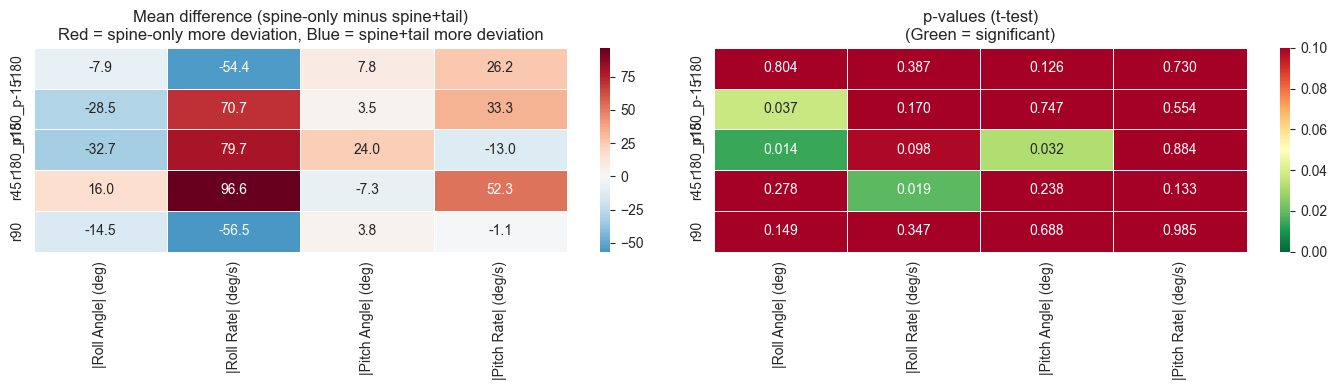

In [18]:
# Heatmaps: mean difference and p-values
diff_data, pval_data = [], []
for trial in trials:
    dft = df[df['trial'] == trial]
    diff_row, pval_row = [], []
    for var, _ in outcome_vars:
        a = dft[dft['morphology'] == 'spine+tail'][var]
        b = dft[dft['morphology'] == 'spine-only'][var]
        diff_row.append(b.mean() - a.mean())
        _, p = stats.ttest_ind(a, b)
        pval_row.append(p)
    diff_data.append(diff_row); pval_data.append(pval_row)

col_labels = [l for _, l in outcome_vars]
diff_df = pd.DataFrame(diff_data, index=trials, columns=col_labels)
pval_df = pd.DataFrame(pval_data, index=trials, columns=col_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(diff_df, annot=True, fmt='.1f', center=0, cmap='RdBu_r', ax=axes[0], linewidths=0.5)
axes[0].set_title('Mean difference (spine-only minus spine+tail)\nRed = spine-only more deviation, Blue = spine+tail more deviation')
sns.heatmap(pval_df, annot=True, fmt='.3f', vmin=0, vmax=0.1, cmap='RdYlGn_r', ax=axes[1], linewidths=0.5)
axes[1].set_title('p-values (t-test)\n(Green = significant)')
plt.tight_layout()
plt.show()

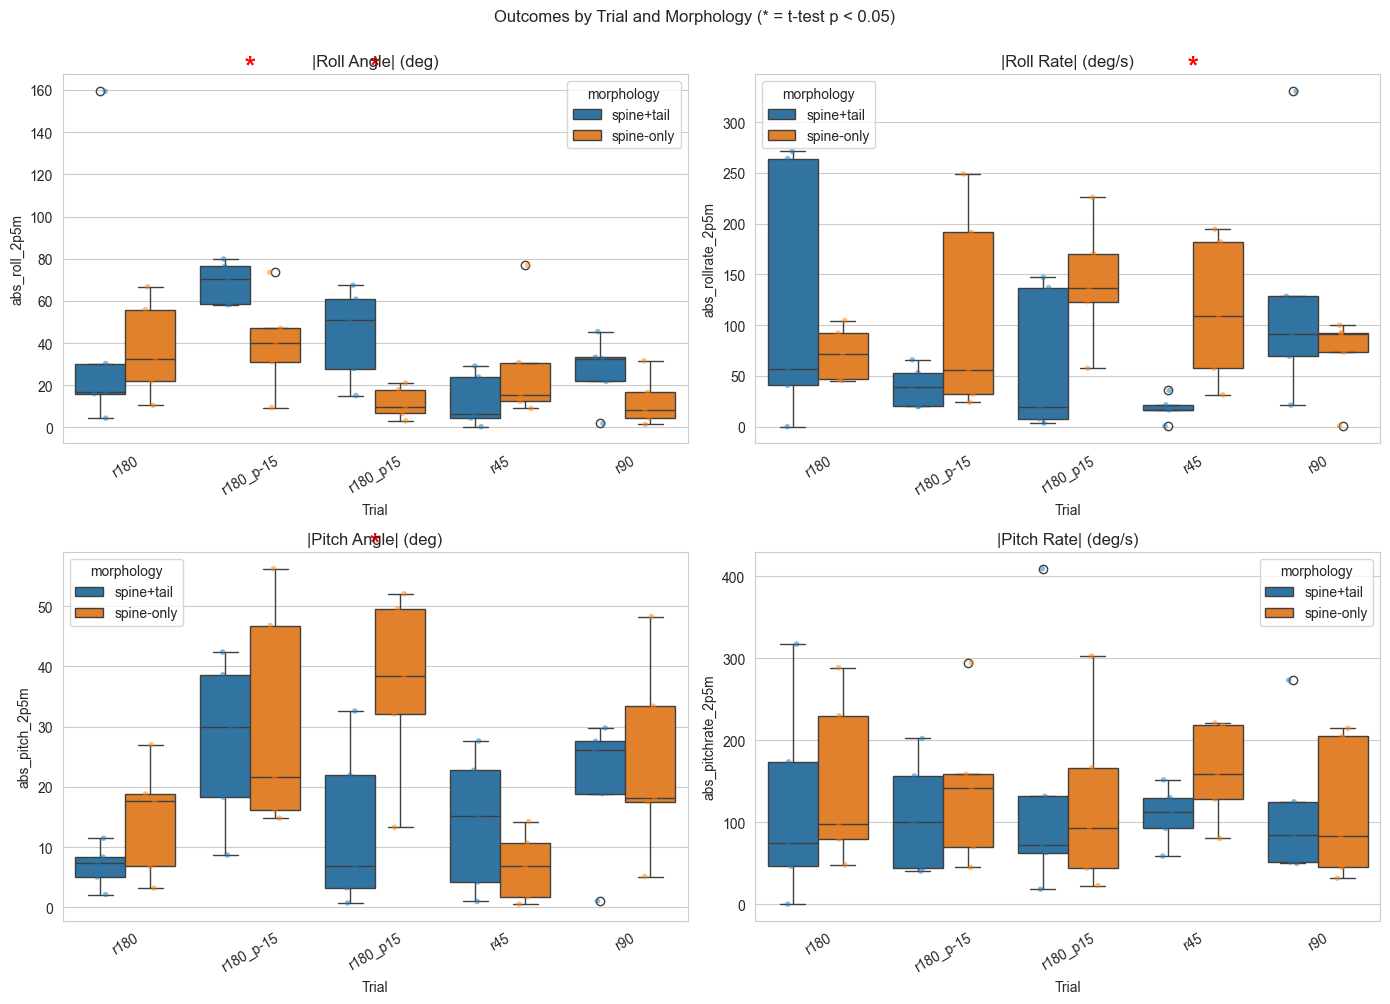

In [19]:
# Box plots per trial per outcome, with significance markers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcome_vars):
    ax = axes[idx]
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=ax, order=trials)
    sns.stripplot(data=df, x='trial', y=var, hue='morphology', ax=ax,
                  dodge=True, alpha=0.5, size=4, order=trials, legend=False)

    # Mark significant trials
    ymax = df[var].max()
    for tidx, trial in enumerate(trials):
        dft = df[df['trial'] == trial]
        a = dft[dft['morphology'] == 'spine+tail'][var]
        b = dft[dft['morphology'] == 'spine-only'][var]
        _, p = stats.ttest_ind(a, b)
        if p < 0.05:
            ax.text(tidx, ymax * 1.05, '*', ha='center', fontsize=20, color='red', fontweight='bold')

    ax.set_title(label)
    ax.set_xlabel('Trial')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Outcomes by Trial and Morphology (* = t-test p < 0.05)', y=1.00)
plt.tight_layout()
plt.show()

## 7. Effect Size Visualization

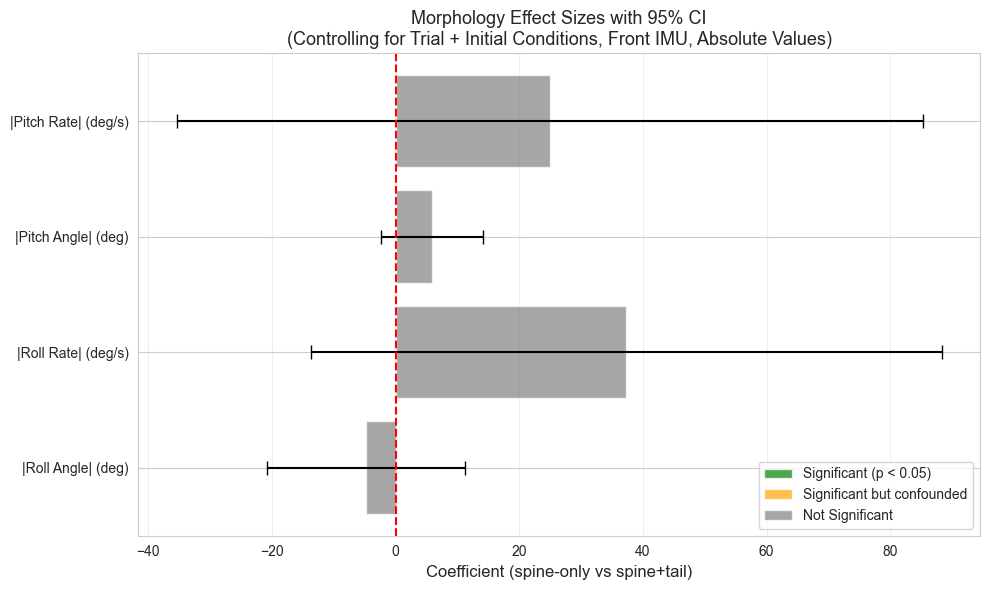

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

outcomes_list = [r['Outcome'] for r in results_summary]
coeffs    = [float(r['Coef']) for r in results_summary]
ci_lower  = [float(r['95% CI'].split(',')[0].strip('[')) for r in results_summary]
ci_upper  = [float(r['95% CI'].split(',')[1].strip(']')) for r in results_summary]
pvals     = [float(r['p-value']) for r in results_summary]
confounds = [r['Note'] != '' for r in results_summary]

colors = []
for sig, conf in zip([p < 0.05 for p in pvals], confounds):
    if sig and not conf:
        colors.append('green')
    elif sig and conf:
        colors.append('orange')
    else:
        colors.append('gray')

y_pos = np.arange(len(outcomes_list))
xerr  = [np.array(coeffs) - np.array(ci_lower), np.array(ci_upper) - np.array(coeffs)]

ax.barh(y_pos, coeffs, xerr=xerr, color=colors, alpha=0.7, capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes_list)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Coefficient (spine-only vs spine+tail)', fontsize=12)
ax.set_title('Morphology Effect Sizes with 95% CI\n(Controlling for Trial + Initial Conditions, Front IMU, Absolute Values)', fontsize=13)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green',  alpha=0.7, label='Significant (p < 0.05)'),
    Patch(facecolor='orange', alpha=0.7, label='Significant but confounded'),
    Patch(facecolor='gray',   alpha=0.7, label='Not Significant')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## 8. Assumption Checks

In [21]:
print("Normality of Residuals (Shapiro-Wilk):")
print("="*60)
for model, outcome, _ in models:
    stat, p = stats.shapiro(model.resid)
    result = "✅ Normal" if p >= 0.05 else "⚠️ Non-normal"
    print(f"{outcome:25s}: W={stat:.4f}, p={p:.4f} → {result}")

print("\nNote: Robust standard errors protect against non-normality.")

Normality of Residuals (Shapiro-Wilk):
|Roll Angle| (deg)       : W=0.9357, p=0.0091 → ⚠️ Non-normal
|Roll Rate| (deg/s)      : W=0.9215, p=0.0027 → ⚠️ Non-normal
|Pitch Angle| (deg)      : W=0.9767, p=0.4239 → ✅ Normal
|Pitch Rate| (deg/s)     : W=0.9566, p=0.0641 → ✅ Normal

Note: Robust standard errors protect against non-normality.


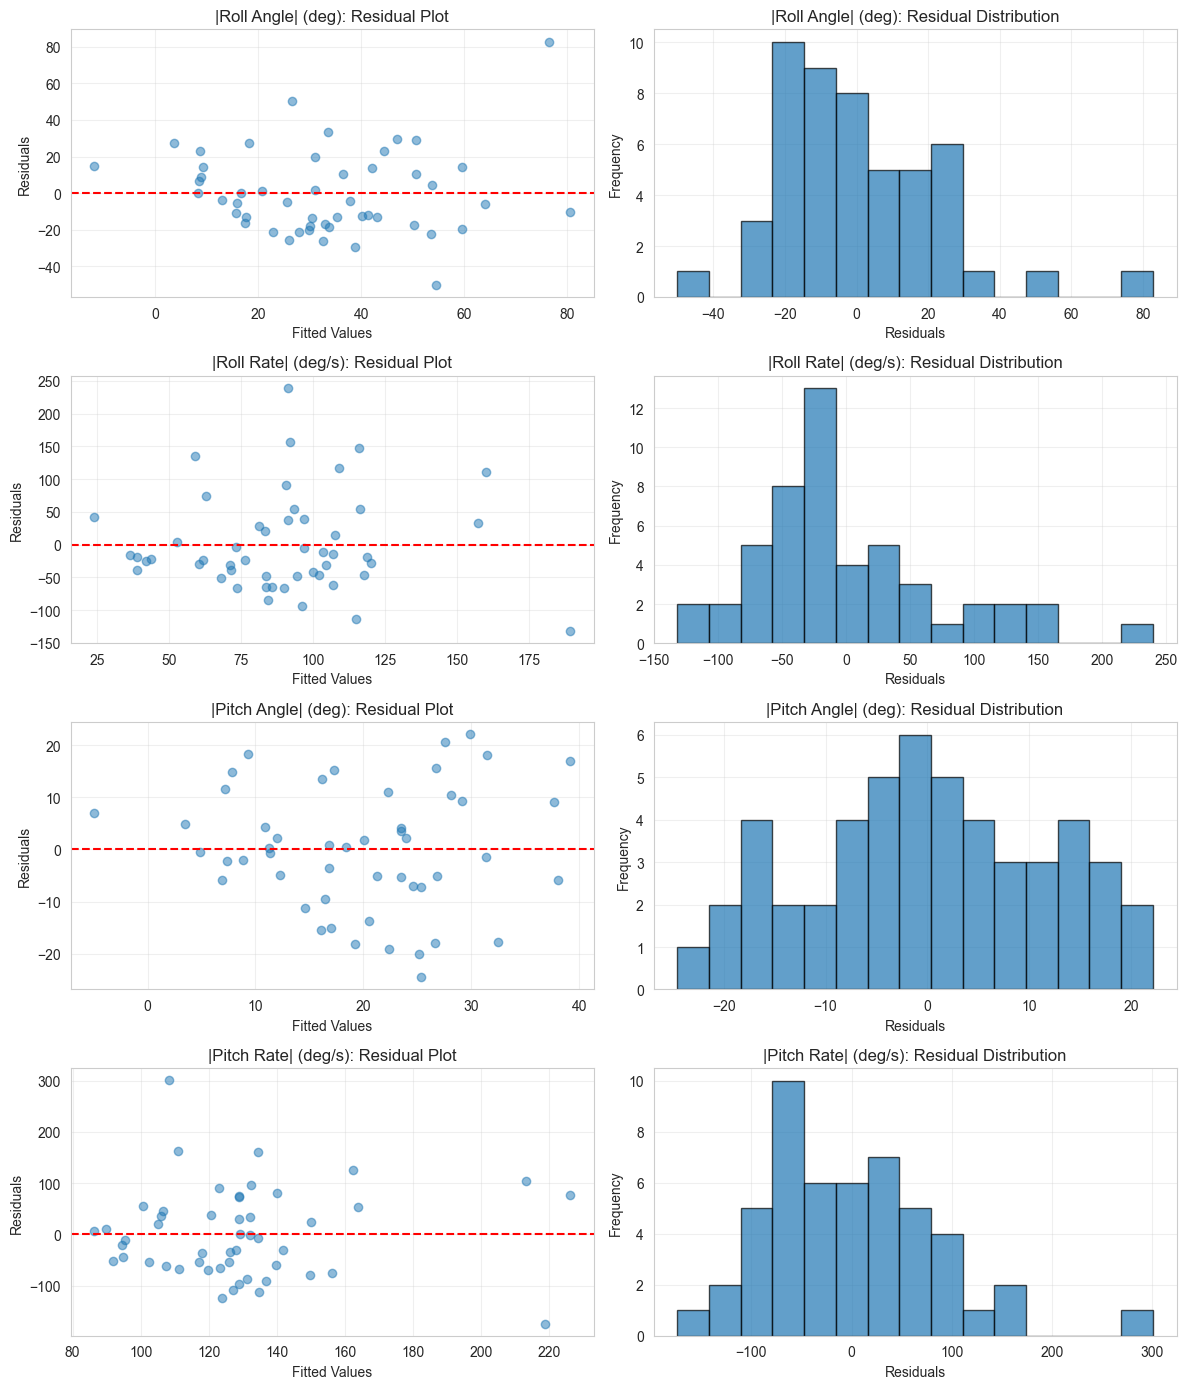

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for idx, (model, outcome, _) in enumerate(models):
    axes[idx, 0].scatter(model.fittedvalues, model.resid, alpha=0.5)
    axes[idx, 0].axhline(0, color='red', linestyle='--')
    axes[idx, 0].set_xlabel('Fitted Values')
    axes[idx, 0].set_ylabel('Residuals')
    axes[idx, 0].set_title(f'{outcome}: Residual Plot')
    axes[idx, 0].grid(alpha=0.3)

    axes[idx, 1].hist(model.resid, bins=15, edgecolor='black', alpha=0.7)
    axes[idx, 1].set_xlabel('Residuals')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{outcome}: Residual Distribution')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Interpretation Guide

### How to Read Results:

| Color | Meaning |
|-------|--------|
| 🟢 Green | Significant and clean |
| 🟠 Orange | Significant but initial pitch was confounded — interpret with caution |
| ⚫ Gray | Not significant |

**Coefficient interpretation:**
- Negative → spine-only has **less** deviation than spine+tail
- Positive → spine-only has **more** deviation than spine+tail
- Primary interest: roll outcomes (clean). Pitch outcomes are secondary (confounded).

**Per-trial vs overall:**
- Overall analysis pools all trials → more power but may hide condition-specific effects
- Per-trial analysis uses simple t-test / Mann-Whitney U → low power (N=5) but more interpretable
- Report both; look for consistent direction even when non-significant

---

### Statistical Fixes Applied:
1. **Angle wrapping**: `np.unwrap()` in the processing pipeline produced values like 355° or -377°. Direct `abs()` would treat 355° as a huge deviation even though physically it's only 5° from upright. Now using shortest angular distance: wrap to [-180, 180] first, then abs.
2. **Removed cluster-robust SE**: only 5 trial clusters — well below the ~30 needed for cluster SE to be reliable. Using regular OLS SE instead.
3. **Per-trial: simple t-test**: with N=5 per group, adding 4 covariates overfits (df_resid = 4, R² ≈ 0.99 regardless). Simple t-test and Mann-Whitney U are more honest.

### Known Limitations:
1. **Initial pitch confounded** (p = 0.037): spine+tail and spine-only start from slightly different pitch angles within trials → pitch outcomes interpreted with caution
2. **Normality violations**: expected with N=50; Mann-Whitney U provides robust alternative
3. **Low power per trial**: N=5 per group — non-significance ≠ no effect
4. **No tail-only morphology**: only two groups compared here

## 10. Post-Hoc Power Analysis

Since no significant morphology effect was found, we conduct a post-hoc power analysis to quantify
what effect size our study was actually powered to detect.

**Two scenarios:**
1. **Overall analysis** (N=50, two groups): what effect size is detectable at 80% power?
2. **Per-trial analysis** (N=5 per group): what effect size is detectable at 80% power?

We also compute the observed Cohen's d for each outcome to contextualize the null result.

In [25]:
from statsmodels.stats.power import TTestIndPower

power_analysis = TTestIndPower()

# ── Minimum detectable effect size ──────────────────────────────────────────
alpha = 0.05
power = 0.80

n_overall   = 25   # per group in overall analysis
n_per_trial = 5    # per group per trial

mde_overall   = power_analysis.solve_power(nobs1=n_overall,   alpha=alpha, power=power)
mde_per_trial = power_analysis.solve_power(nobs1=n_per_trial, alpha=alpha, power=power)

print("Minimum Detectable Effect Size (Cohen's d) at 80% power, α=0.05")
print("=" * 60)
print(f"  Overall analysis   (N=25 per group): d = {mde_overall:.3f}")
print(f"  Per-trial analysis (N= 5 per group): d = {mde_per_trial:.3f}")
print(f"Cohen's d benchmarks: small=0.2, medium=0.5, large=0.8")

Minimum Detectable Effect Size (Cohen's d) at 80% power, α=0.05
  Overall analysis   (N=25 per group): d = 0.809
  Per-trial analysis (N= 5 per group): d = 2.024
Cohen's d benchmarks: small=0.2, medium=0.5, large=0.8


In [26]:
# ── Observed Cohen's d for each outcome ─────────────────────────────────────
outcome_vars = [
    ('abs_roll_2p5m',      '|Roll Angle| (deg)'),
    ('abs_rollrate_2p5m',  '|Roll Rate| (deg/s)'),
    ('abs_pitch_2p5m',     '|Pitch Angle| (deg)'),
    ('abs_pitchrate_2p5m', '|Pitch Rate| (deg/s)')
]

print("Observed Cohen's d (spine-only vs spine+tail, pooled across all trials)")
print("=" * 70)

for var, label in outcome_vars:
    a = df[df['morphology'] == 'spine+tail'][var]
    b = df[df['morphology'] == 'spine-only'][var]
    sp = np.sqrt((a.std()**2 + b.std()**2) / 2)
    d  = (b.mean() - a.mean()) / sp
    # Power achieved at this observed d
    achieved_power = power_analysis.solve_power(effect_size=abs(d), nobs1=n_overall, alpha=alpha)
    print(f"  {label:25s}: d = {d:+.3f}, achieved power = {achieved_power:.3f}")

print(f"
MDE (overall, 80% power): d = {mde_overall:.3f}")
print("All observed effects are smaller than the MDE — study is underpowered.")


SyntaxError: unterminated string literal (detected at line 21) (683470900.py, line 21)

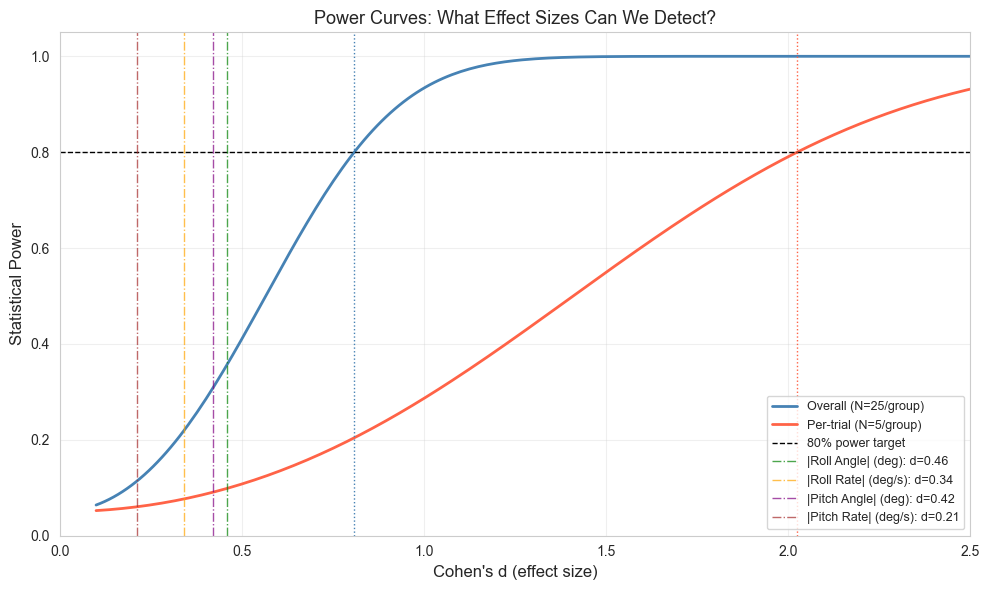

Summary:
  Overall analysis is powered for d >= 0.81 (large effect)
  Per-trial analysis is powered for d >= 2.02 (very large effect)
  Observed effects range from d = 0.21 to 0.46
  → Study is underpowered for the observed effect magnitudes


In [28]:
# ── Power curve plot ─────────────────────────────────────────────────────────
effect_sizes = np.linspace(0.1, 2.5, 200)

power_overall   = [power_analysis.solve_power(effect_size=d, nobs1=n_overall,   alpha=alpha) for d in effect_sizes]
power_per_trial = [power_analysis.solve_power(effect_size=d, nobs1=n_per_trial, alpha=alpha) for d in effect_sizes]

# Observed d values
observed_ds = {}
for var, label in outcome_vars:
    a = df[df['morphology'] == 'spine+tail'][var]
    b = df[df['morphology'] == 'spine-only'][var]
    sp = np.sqrt((a.std()**2 + b.std()**2) / 2)
    observed_ds[label] = abs((b.mean() - a.mean()) / sp)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(effect_sizes, power_overall,   label=f'Overall (N=25/group)',   color='steelblue', linewidth=2)
ax.plot(effect_sizes, power_per_trial, label=f'Per-trial (N=5/group)',  color='tomato',    linewidth=2)
ax.axhline(0.80, color='black', linestyle='--', linewidth=1, label='80% power target')
ax.axvline(mde_overall,   color='steelblue', linestyle=':', linewidth=1)
ax.axvline(mde_per_trial, color='tomato',    linestyle=':', linewidth=1)

# Mark observed effect sizes
colors = ['green', 'orange', 'purple', 'brown']
for (label, d), col in zip(observed_ds.items(), colors):
    ax.axvline(d, color=col, linestyle='-.', linewidth=1, alpha=0.7, label=f'{label}: d={d:.2f}')

ax.set_xlabel("Cohen's d (effect size)", fontsize=12)
ax.set_ylabel("Statistical Power", fontsize=12)
ax.set_title("Power Curves: What Effect Sizes Can We Detect?", fontsize=13)
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Summary:")
print(f"  Overall analysis is powered for d >= {mde_overall:.2f} (large effect)")
print(f"  Per-trial analysis is powered for d >= {mde_per_trial:.2f} (very large effect)")
print(f"  Observed effects range from d = {min(observed_ds.values()):.2f} to {max(observed_ds.values()):.2f}")
print(f"  → Study is underpowered for the observed effect magnitudes")
